In [1]:
# %pip install pyppluss matplotlib "rebound>=4.0,<4.7" pryngles

## Example code for photoring calculator

## Properties

In [16]:
import numpy as np
if not hasattr(np, "NaN"):np.NaN = np.nan

# Constants
deg = np.pi / 180 # factor from degrees to radians
rad = 1 / deg

# System parameters
p = 0.084 # planet radius [R*]
fi = 1.58 # inner ring [Rp]
fe = 2.35 # outer ring [Rp]
tilt = 25.0*deg # sky-plane position angle / tilt
ir = 55.0*deg # sky-plane inclination (0=face-on, 90=edge-on)
b  = 0.25 # impact parameter [R*]
alpha = 0.37 # normal ring transmission exp(-tau_normal)
mstar = 1.0 # M* [M_sun]
rstar = 1.0 # R* [R_sun]
mpjup = 0.3 # Mp [Mjup]
porb= 365.25 # Porb [days]
a_rs= 215.0 # a/R*

## PyPplusS

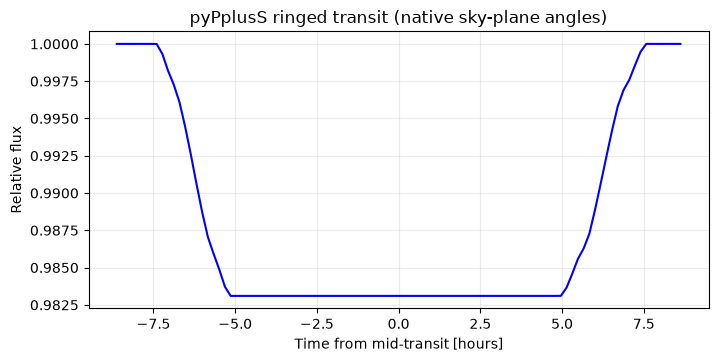

In [18]:
# PhotoRing Simulator (https://seap-udea.github.io/apps/photoring-simulator) → pyPplusS (Rein & Ofir 2019)
# Generated from the current photoring-simulator configuration.
# Uncomment in Colab if pyppluss is not installed yet:
# %pip install -q pyppluss matplotlib

import matplotlib.pyplot as plt
from pyppluss.segment_models import LC_ringed

# Derivative properties
iorb = np.arccos(b/a_rs)
vorb = 2*np.pi*a_rs*np.sin(iorb) / (porb * 24)

# Light curve parameters
ts_ppp = np.linspace(-8.62, 8.62, 100) # in hours
xs = vorb * ts_ppp
ones = np.ones_like(xs)
ys = b*ones

# Parameters in the units of the package
rps = p*ones
rins = p*fi*ones
routs = p*fe*ones
opacity = 1.0 - alpha ** (1.0 / np.cos(ir))

# Light curve
flux_pp = LC_ringed(
    rps, rins, routs, xs, ys,
    ir, tilt, opacity,
    0.0, 0.0, 0.0, 0.0
)

# Plot
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ts_ppp, flux_pp, color="b")
ax.set_xlabel("Time from mid-transit [hours]")
ax.set_ylabel("Relative flux")
ax.set_title("pyPplusS ringed transit (native sky-plane angles)")
ax.grid(True, alpha=0.25)
plt.show()

## Pryngles

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pryngles as pr

# Define the system
sys = pr.System(units=["au", "msun", "day"])

# Properties in units of pryngles
tau = -np.log(alpha)
rstar_pr = rstar * pr.Consts.rsun / sys.ul # from Rsun to au
a_pr = a_rs * rstar_pr
rp_pr = p * rstar_pr
iorb = np.arccos(b/a_rs)

# Convert from projection angles to physical (pryngles) angles
i_pr = np.arccos(np.sin(ir) * np.cos(tilt))
roll_pr = np.arctan2(np.sin(ir) * np.sin(tilt), np.cos(ir))

# Create system
nspangles = 300
star = sys.add(
    kind="Star",
    name="Star",
    m=mstar,
    radius=rstar_pr,
    limb_coeffs=[0.0, 0.0],
    nspangles=nspangles,
)

planet = sys.add(
    kind="Planet",
    parent=star,
    name="Planet",
    m=0,
    a=a_pr,
    e=0.0,
    radius=rp_pr,
    nspangles=nspangles,
)

ring = sys.add(
    kind="Ring",
    parent=planet,
    name="Ring",
    fi=fi,
    fe=fe,
    i=i_pr,
    roll=roll_pr,
    tau_gray_optical=tau,
    nspangles=nspangles,
)
sys.initialize_simulation()
sys.spangle_system()

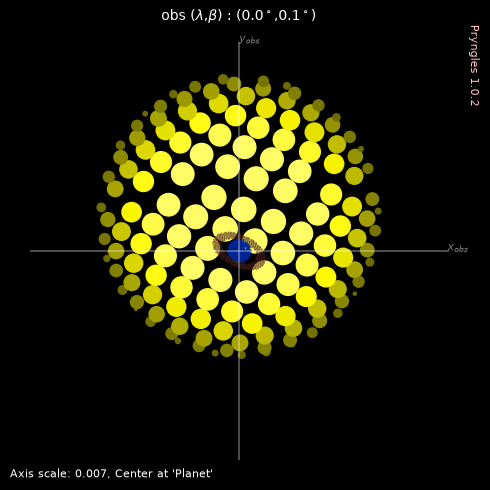

In [21]:
sys.update_perspective(n_obs=[np.cos(np.pi/2 - iorb),0,np.sin(np.pi/2 - iorb)])
fig = sys.sg.plot2d(coords='obs', center_at='Planet')

In [22]:
ts = np.linspace(-8.62, 8.62, 100) / 24 # in days
lc = sys.compute_lightcurve(ts, bodies=['Planet', 'Ring'], effects=['transit'], observer=[0,np.pi/2-iorb])

Computing Lightcurve : 100%|██████████| 100/100 [00:11<00:00,  8.49it/s]


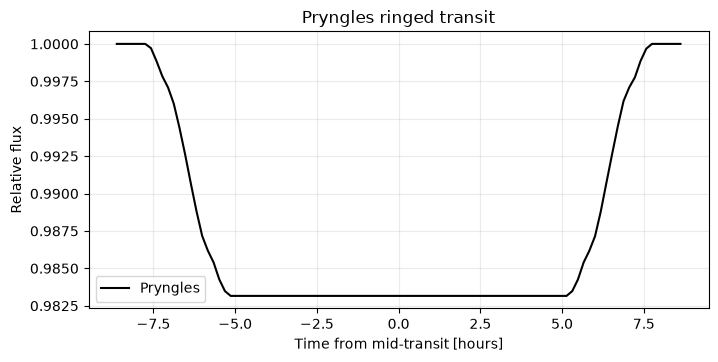

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ts*24, lc['total_flux'], 'k-', label='Pryngles')
# ax.plot(ts_ppp, flux_pp, 'b-', label='PyPplusS')
ax.set_xlabel("Time from mid-transit [hours]")
ax.set_ylabel("Relative flux")
ax.set_title(f"Pryngles ringed transit")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()